# Full Transformer 版（1-head, 1-layer）

`paper_reproduce.ipynb` をベースに、以下へ固定した最小構成です。

- `w0` 初期化: ガウス乱数に固定
- 学習: no-CoT（`Z0` から1回読み出して `w*` を回帰）
- 正則化: Attention パラメータに L2 正則化
- Attention: softmax self-attention（1-head）
- 学習パラメータ: `W_Q, W_K, W_V, W_O`

不要な機能（学習モード切替、`w0` 切替、CoT 学習分岐など）は削除しています。

In [137]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ===== 実験設定（固定） =====
D = 10
N = 500
BATCH_SIZE = 512
ADAM_LR = 1.0
PARAM_L2_LAMBDA = 0.00001
ITERATIONS = 2000
EVAL_K_LIST = [0, 1, 2, 3, 4, 6, 8, 10]
SIGMA = 0.0001  # 全タスク共通ノイズ標準偏差
SEED = 427

DE = 2 * D + 2
ATTN_OUTPUT_GAIN = 1.0 / np.sqrt(DE)  # tauは導入せず、出力側ゲインのみ

np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(
    f"device={device}, d={D}, n={N}, B={BATCH_SIZE}, "
    f"iters={ITERATIONS}, lr={ADAM_LR}, l2={PARAM_L2_LAMBDA}, "
    f"sigma={SIGMA}, out_gain={ATTN_OUTPUT_GAIN:.4f}"
)

device=cpu, d=10, n=500, B=512, iters=2000, lr=1.0, l2=1e-05, sigma=0.0001, out_gain=0.2132


In [138]:
def sample_batch(batch_size, d=D, n=N, device=device):
    """
    x_{mu,l} ~ N(0, I_D / D),
    y_{mu,l} = w_mu^T x_{mu,l} + eps_{mu,l}, eps_{mu,l} ~ N(0, SIGMA^2)
    """
    X = torch.randn(batch_size, d, n, device=device) / np.sqrt(d)
    w_star = torch.randn(batch_size, d, device=device)

    clean = torch.einsum("bd,bdn->bn", w_star, X)
    eps = SIGMA * torch.randn(batch_size, n, device=device)
    y = clean + eps

    return X, y, w_star


def sample_w0_random(batch_size, d=D, device=device):
    # w0 はガウス乱数に固定
    return torch.randn(batch_size, d, device=device)


def build_Z(X, y, w_prefix):
    B, d, n = X.shape
    i = len(w_prefix) - 1
    L = n + i + 1

    Z = torch.zeros(B, DE, L, device=X.device)
    Z[:, :d, :n] = X
    Z[:, d, :n] = y

    for t, w_t in enumerate(w_prefix):
        col = n + t
        Z[:, d + 1 : d + 1 + d, col] = w_t

    Z[:, -1, :] = 1.0
    return Z


def f_transformer_last(Z, W_Q, W_K, W_V, W_O, output_gain=ATTN_OUTPUT_GAIN):
    """
    1-head, 1-layer の full softmax self-attention + residual。
    
    Q = W_Q Z, K = W_K Z, V = W_V Z
    query は最終トークン列のみを使用して attention を計算し、
    output = z_last + output_gain * (W_O @ context) を返す。
    """
    z_last = Z[:, :, -1]                                  # [B, DE]
    q = torch.einsum("ij,bj->bi", W_Q, z_last)          # [B, DE]
    K = torch.einsum("ij,bjl->bil", W_K, Z)             # [B, DE, L]
    Vproj = torch.einsum("ij,bjl->bil", W_V, Z)         # [B, DE, L]

    scores = torch.einsum("bil,bi->bl", K, q) / np.sqrt(DE)  # [B, L]
    attn = torch.softmax(scores, dim=-1)                  # [B, L]
    context = torch.einsum("bil,bl->bi", Vproj, attn)    # [B, DE]

    out_last = z_last + output_gain * torch.einsum("ij,bj->bi", W_O, context)
    return out_last


def no_cot_train_loss(W_Q, W_K, W_V, W_O, X, y, w_star):
    B = X.shape[0]
    w0 = sample_w0_random(B, D, X.device)
    Z0 = build_Z(X, y, [w0])
    pred = f_transformer_last(Z0, W_Q, W_K, W_V, W_O)

    # 学習は w ブロックの誤差のみを最小化（D で正規化された MSE）
    w_hat = pred[:, D + 1 : D + 1 + D]
    loss = 0.5 * ((w_hat - w_star) ** 2).mean(dim=1).mean()
    return loss


def eval_loss(W_Q, W_K, W_V, W_O, k_eval, batch_size=2048):
    # 推論時は noise-free タスクを使用
    X = torch.randn(batch_size, D, N, device=device) / np.sqrt(D)
    w_star = torch.randn(batch_size, D, device=device)
    y = torch.einsum("bd,bdn->bn", w_star, X)

    with torch.no_grad():
        # 推論時は w0 = 0 に固定
        w0 = torch.zeros(batch_size, D, device=device)
        w_prefix = [w0]

        # k_eval 回だけ Read(Atten(P_t)) を適用
        for _ in range(k_eval):
            Z = build_Z(X, y, w_prefix)
            pred = f_transformer_last(Z, W_Q, W_K, W_V, W_O)
            w_hat = pred[:, D + 1 : D + 1 + D]
            w_prefix.append(w_hat)

        # k_eval=0 なら w_hat_final = w0(=0)
        w_hat_final = w_prefix[-1]

        # w ブロックのMSEで評価
        loss = ((w_hat_final - w_star) ** 2).mean(dim=1).mean().item()

    return loss


def parameter_l2_penalty(W_Q, W_K, W_V, W_O):
    return W_Q.pow(2).sum() + W_K.pow(2).sum() + W_V.pow(2).sum() + W_O.pow(2).sum()

In [139]:
def train_model_no_cot_transformer(iterations=ITERATIONS, log_every=10):
    W_Q = nn.Parameter(0.01 * torch.randn(DE, DE, device=device))
    W_K = nn.Parameter(0.01 * torch.randn(DE, DE, device=device))
    W_V = nn.Parameter(0.01 * torch.randn(DE, DE, device=device))
    W_O = nn.Parameter(0.01 * torch.randn(DE, DE, device=device))
    opt = torch.optim.Adam([W_Q, W_K, W_V, W_O], lr=ADAM_LR)

    train_curve = []
    for t in range(iterations):
        X, y, w_star = sample_batch(BATCH_SIZE)
        data_loss = no_cot_train_loss(W_Q, W_K, W_V, W_O, X, y, w_star)
        reg_loss = PARAM_L2_LAMBDA * parameter_l2_penalty(W_Q, W_K, W_V, W_O)
        loss = data_loss + reg_loss

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        if t % log_every == 0:
            train_curve.append(float(data_loss.detach().cpu()))

    return W_Q.detach(), W_K.detach(), W_V.detach(), W_O.detach(), np.array(train_curve)


print("training full-transformer attention / no-CoT / w0=Gaussian / L2 ...")
W_Q_tr, W_K_tr, W_V_tr, W_O_tr, train_curve = train_model_no_cot_transformer(iterations=ITERATIONS)

final_eval = {}
for k_eval in EVAL_K_LIST:
    final_eval[k_eval] = eval_loss(W_Q_tr, W_K_tr, W_V_tr, W_O_tr, k_eval=k_eval)

print("done")
for k_eval in EVAL_K_LIST:
    print(f"k_eval={k_eval:>2}: {final_eval[k_eval]:.6f}")

training full-transformer attention / no-CoT / w0=Gaussian / L2 ...
done
k_eval= 0: 1.007259
k_eval= 1: 0.111604
k_eval= 2: 0.185795
k_eval= 3: 0.284015
k_eval= 4: 0.383541
k_eval= 6: 0.485696
k_eval= 8: 0.545970
k_eval=10: 0.802792


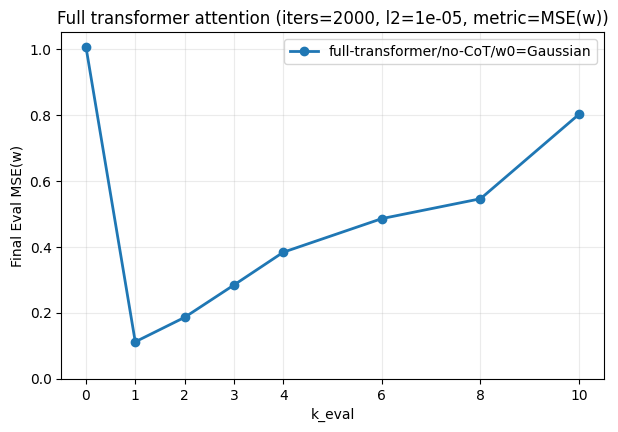

In [140]:
# ===== 可視化（loss のみ） =====
ks = np.array(sorted(final_eval.keys()))
vals = np.array([final_eval[k] for k in ks])

plt.figure(figsize=(7, 4.5))
plt.plot(ks, vals, marker="o", linewidth=2, label="full-transformer/no-CoT/w0=Gaussian")
plt.xlabel("k_eval")
plt.ylabel("Final Eval MSE(w)")
plt.title(f"Full transformer attention (iters={ITERATIONS}, l2={PARAM_L2_LAMBDA}, metric=MSE(w))")
plt.xticks(ks)
plt.ylim(bottom=0)
plt.grid(alpha=0.25)
plt.legend()
plt.show()